# 06 — Ensemble & Threshold Tuning — **UPDATED**

**Changes:** Loads global `label_encoders.json` from NB05 so abuse_type y_true
matches the 9-class logits. Saves `ensemble_test_metrics.json` for NB07.


In [6]:
import os, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from sklearn.metrics import (f1_score, accuracy_score, matthews_corrcoef,
    classification_report, confusion_matrix, roc_auc_score, average_precision_score)
from sklearn.linear_model import LogisticRegression
from scipy.optimize import minimize_scalar, minimize

warnings.filterwarnings("ignore")
os.makedirs("../outputs/ensemble", exist_ok=True)


In [7]:
MODELS_DIR = "../outputs/models_main"   # main random-split checkpoints from NB05

model_dirs = sorted(glob.glob(f"{MODELS_DIR}/*_seed*"))
print(f"Found {len(model_dirs)} model runs:")
for d in model_dirs: print(f"  {os.path.basename(d)}")

val_logits_all  = {}
test_logits_all = {}

for d in model_dirs:
    name = os.path.basename(d)
    vp   = os.path.join(d, "val_logits.pt")
    tp   = os.path.join(d, "test_logits.pt")
    if os.path.exists(vp) and os.path.exists(tp):
        val_logits_all[name]  = torch.load(vp,  map_location="cpu", weights_only=False)
        test_logits_all[name] = torch.load(tp, map_location="cpu", weights_only=False)
        tasks_avail = list(val_logits_all[name].keys())
        print(f"  ✅ {name}  tasks={tasks_avail}")
    else:
        print(f"  ⚠ {name} — logit files missing, skipping")

print(f"\nLoaded {len(val_logits_all)} runs")


Found 9 model runs:
  banglabert_seed123
  banglabert_seed42
  banglabert_seed456
  muril_seed123
  muril_seed42
  muril_seed456
  xlmr_seed123
  xlmr_seed42
  xlmr_seed456
  ✅ banglabert_seed123  tasks=['abuse_type']
  ✅ banglabert_seed42  tasks=['abuse_type']
  ✅ banglabert_seed456  tasks=['abuse_type']
  ✅ muril_seed123  tasks=['abuse_type']
  ✅ muril_seed42  tasks=['abuse_type']
  ✅ muril_seed456  tasks=['abuse_type']
  ✅ xlmr_seed123  tasks=['abuse_type']
  ✅ xlmr_seed42  tasks=['abuse_type']
  ✅ xlmr_seed456  tasks=['abuse_type']

Loaded 9 runs


In [8]:
# ── Load true labels + apply same consolidation as NB05 ────────────
# CRITICAL: NB05 saves logits for 9 consolidated classes.
# val_df / test_df here have RAW label_type (89 classes) unless we apply the
# same consolidate_type function. We load label_encoders.json to stay in sync.

SPLIT_DIR = "../data/splits"
val_df    = pd.read_csv(f"{SPLIT_DIR}/random_val.csv")
test_df   = pd.read_csv(f"{SPLIT_DIR}/random_test.csv")

# ── Load global label encoders saved by NB05 ───────────────────────
LE_PATH = f"{MODELS_DIR}/label_encoders.json"
assert os.path.exists(LE_PATH), (
    f"label_encoders.json not found at {LE_PATH}. "
    "Run NB05 first and make sure it completes the consolidation cell."
)
with open(LE_PATH) as _f:
    _raw_le = json.load(_f)

# NB05 saves integer keys for binary as strings; restore proper types
label_encoders = {}
for task, enc in _raw_le.items():
    if task == "binary":
        label_encoders[task] = {int(k): v for k, v in enc.items()}
    else:
        label_encoders[task] = enc      # abuse_type keys are strings

# ── Apply same consolidation ────────────────────────────────────────
TYPE_MAP = {
    "none":"none","not bully":"none",
    "threat":"threat","threat,spam":"threat",
    "callToViolence":"threat","callToViolence_slander":"threat",
    "callToViolence_gender":"threat","callToViolence_religion":"threat",
    "callToViolence_religion_slander":"threat",
    "callToViolence_gender_religion_slander":"threat",
    "callToViolence_gender_slander":"threat",
    "religious,threat":"threat","sexual,threat":"threat","sexual,religious,threat":"threat",
    "sexual":"sexual","sexual,religious":"sexual","sexual,spam":"sexual",
    "religious":"religious","Religious":"religious","religion":"religious",
    "religious,spam":"religious","religion_slander":"religious",
    "gender_religion":"religious","gender_religion_slander":"religious",
    "gender":"gender","Gender":"gender","gender_slander":"gender",
    "Political":"political",
    "Personal Offense":"personal","Body Shaming":"personal",
    "Origin":"personal","slander":"personal","Misc":"personal",
    "Abusive/Violence":"abusive","troll":"abusive",
    "spam":"other",
}
PRIORITY = ["threat","sexual","religious","gender","political","abusive","personal","other","none"]

def consolidate_type(val):
    if not isinstance(val, str) or not val.strip(): return "none"
    val = val.strip()
    if val in TYPE_MAP: return TYPE_MAP[val]
    parts = [p.strip() for p in val.replace(";",",").split(",")]
    cands = [TYPE_MAP[p] for p in parts if p in TYPE_MAP]
    if cands:
        for pc in PRIORITY:
            if pc in cands: return pc
    sl = val.lower().replace("_"," ")
    for kw, cls in [("threat","threat"),("calltoviolence","threat"),("sexual","sexual"),
                    ("religious","religious"),("religion","religious"),("gender","gender"),
                    ("political","political"),("abusive","abusive"),("violence","abusive"),
                    ("personal","personal"),("slander","personal"),("origin","personal"),
                    ("body","personal"),("misc","personal"),("spam","other")]:
        if kw in sl.replace(" ",""): return cls
    return "other"

for df_ in [val_df, test_df]:
    df_["label_type"] = df_["label_type"].apply(consolidate_type)

# ── True labels (integer encoded) ──────────────────────────────────
# NOTE: binary labels are NOT used (binary task removed). Kept only for
# optional reference / none-as-binary cross-checks.
y_val_binary  = val_df["label_binary"].values if "label_binary" in val_df.columns else None
y_test_binary = test_df["label_binary"].values if "label_binary" in test_df.columns else None

# abuse_type: encode consolidated strings → integers using NB05's mapping
abuse_enc = label_encoders["abuse_type"]
y_val_abuse  = np.array([abuse_enc.get(str(v), -1) for v in val_df["label_type"]])
y_test_abuse = np.array([abuse_enc.get(str(v), -1) for v in test_df["label_type"]])

print(f"Val  size: {len(val_df):,}   binary classes: {np.unique(y_val_binary)}")
print(f"Test size: {len(test_df):,}   abuse classes : {np.unique(y_val_abuse[y_val_abuse>=0])}")
print(f"abuse_type encoder: {abuse_enc}")


Val  size: 9,434   binary classes: [0 1]
Test size: 9,434   abuse classes : [0 1 2 3 4 5 6 7 8]
abuse_type encoder: {'abusive': 0, 'gender': 1, 'none': 2, 'other': 3, 'personal': 4, 'political': 5, 'religious': 6, 'sexual': 7, 'threat': 8}


## 1 — Weighted Logits Ensemble (abuse-type, single-task)

In [9]:
def ensemble_logits(logits_dict, weights, task="binary"):
    names = list(logits_dict.keys())
    assert len(weights) == len(names)
    out = None
    for i, name in enumerate(names):
        l = logits_dict[name][task].float()
        out = weights[i] * l if out is None else out + weights[i] * l
    return out / sum(weights)


def optimize_weights(val_logits_dict, y_true, task="binary", n_cls=2):
    names = list(val_logits_dict.keys())
    n     = len(names)

    def neg_f1(raw_w):
        w = np.abs(raw_w) + 1e-8
        ens = ensemble_logits(val_logits_dict, w, task)
        preds = ens.argmax(-1).numpy()
        return -f1_score(y_true, preds, average="macro", zero_division=0)

    best_val, best_w = 1.0, None
    for _ in range(50):
        w0 = np.random.dirichlet(np.ones(n))
        res = minimize(neg_f1, w0, method="Nelder-Mead",
                       options={"maxiter": 2000, "xatol": 1e-5})
        if res.fun < best_val:
            best_val, best_w = res.fun, np.abs(res.x) + 1e-8

    best_w = best_w / best_w.sum()
    print(f"Optimised {task} ensemble weights (sum=1):")
    for name, w in zip(names, best_w):
        print(f"  {name}: {w:.4f}")
    print(f"Val macro-F1 (optimised): {-best_val:.4f}")
    return best_w


if len(val_logits_all) == 0:
    print("❌ No logits loaded — run NB05 first")
    opt_weights = None
else:
    print("Optimising ensemble weights on validation set (TARGET: abuse-type macro-F1)...")
    n_abuse = len(label_encoders["abuse_type"])
    opt_weights = optimize_weights(val_logits_all, y_val_abuse, "abuse_type", n_cls=n_abuse)


Optimising ensemble weights on validation set (TARGET: abuse-type macro-F1)...
Optimised abuse_type ensemble weights (sum=1):
  banglabert_seed123: 0.1656
  banglabert_seed42: 0.1608
  banglabert_seed456: 0.1291
  muril_seed123: 0.0966
  muril_seed42: 0.0528
  muril_seed456: 0.0244
  xlmr_seed123: 0.0968
  xlmr_seed42: 0.0338
  xlmr_seed456: 0.2401
Val macro-F1 (optimised): 0.6834


In [10]:
# ── Logit Adjustment (Menon et al., ICLR 2021) — no retraining needed ────────
enc_la = label_encoders["abuse_type"]
n_cls_la = len(enc_la)

# Class priors from training split only (no leakage)
_tr = pd.read_csv("../data/splits/random_train.csv")
counts_la = np.zeros(n_cls_la)
for cls, idx in enc_la.items():
    counts_la[idx] = (_tr["label_type"] == cls).sum()
priors_la = counts_la / counts_la.sum()
print("Class priors used for logit adjustment:")
for cls, idx in sorted(enc_la.items(), key=lambda x: x[1]):
    print(f"  {cls:12s}: prior={priors_la[idx]:.5f}  n_train={int(counts_la[idx])}")

def logit_adjust(logits, priors, tau=1.0):
    lp = torch.tensor(np.log(priors + 1e-12), dtype=logits.dtype)
    return logits - tau * lp   # boosts rare classes (low prior → large +shift)

# Tune τ on VAL (abuse-type macro-F1, no test data touched)
ens_val_raw = ensemble_logits(val_logits_all, opt_weights, "abuse_type")
vm = y_val_abuse >= 0
print("\nTuning τ on validation set:")
best_tau, best_vf1 = 1.0, -1.0
for tau in [0.0, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]:
    yp_v = logit_adjust(ens_val_raw, priors_la, tau).argmax(-1).numpy()[vm]
    vf1  = f1_score(y_val_abuse[vm], yp_v, average="macro", zero_division=0)
    mark = "  ✅" if vf1 > best_vf1 else ""
    print(f"  τ={tau:.2f}  val macro-F1={vf1:.4f}{mark}")
    if vf1 > best_vf1:
        best_vf1, best_tau = vf1, tau
print(f"\n→ Using τ={best_tau}  (val macro-F1: {best_vf1:.4f})")

Class priors used for logit adjustment:
  abusive     : prior=0.00000  n_train=0
  gender      : prior=0.00588  n_train=247
  none        : prior=0.60231  n_train=25291
  other       : prior=0.00000  n_train=0
  personal    : prior=0.00000  n_train=0
  political   : prior=0.00000  n_train=0
  religious   : prior=0.15618  n_train=6558
  sexual      : prior=0.19428  n_train=8158
  threat      : prior=0.04134  n_train=1736

Tuning τ on validation set:
  τ=0.00  val macro-F1=0.6834  ✅
  τ=0.50  val macro-F1=0.1198
  τ=0.75  val macro-F1=0.1198
  τ=1.00  val macro-F1=0.1198
  τ=1.25  val macro-F1=0.1198
  τ=1.50  val macro-F1=0.1198
  τ=2.00  val macro-F1=0.1198
  τ=2.50  val macro-F1=0.1198
  τ=3.00  val macro-F1=0.1198

→ Using τ=0.0  (val macro-F1: 0.6834)


## 2 — (Removed) Threshold Tuning — not applicable to single-task multiclass

In [11]:
# ── No threshold tuning in single-task multiclass setting ───────────────────
# Binary has been removed entirely. The 9-class abuse-type prediction is argmax
# over the ensembled logits — there is no scalar threshold to tune.
print("Single-task abuse-type ensemble: predictions are argmax over 9 classes.")
print("No threshold tuning needed (binary task removed).")
best_threshold = None

Single-task abuse-type ensemble: predictions are argmax over 9 classes.
No threshold tuning needed (binary task removed).


## 3 — (Optional) Stacking Meta-Learner — skipped

In [12]:
# ── Optional stacking meta-learner (abuse-type) — skipped by default ────────
# The weighted-logit ensemble already targets abuse-type macro-F1. A stacking
# meta-learner on 9-class logits is optional; we skip it to keep the pipeline
# simple and avoid overfitting the small validation set.
print("Stacking meta-learner skipped (weighted-logit ensemble is the final system).")

Stacking meta-learner skipped (weighted-logit ensemble is the final system).


## 4 — Final Test Evaluation (abuse-type) + `none`-as-binary equivalent

FINAL ENSEMBLE — abuse-type (9-class) on COMBINED 20% (val+test), n=18,868
  Macro-F1    : 0.6694   <- PRIMARY METRIC
  Weighted-F1 : 0.8028
  Accuracy    : 0.8026
  MCC         : 0.7109
  Macro-AUROC : 0.9429
  `none`-class F1 (binary-equivalent): 0.8683
  Binary-equiv (none vs rest): F1=0.8631  Acc=0.8633  MCC=0.7262

Per-class report (20% pool):
              precision    recall  f1-score   support

     abusive       0.72      0.71      0.72      2615
      gender       0.48      0.21      0.29       113
        none       0.87      0.86      0.87      9844
       other       0.79      0.72      0.76       145
    personal       0.53      0.59      0.56      1507
   political       0.38      0.35      0.36       234
   religious       0.90      0.87      0.88      1710
      sexual       0.78      0.81      0.80      2053
      threat       0.76      0.81      0.79       647

    accuracy                           0.80     18868
   macro avg       0.69      0.66      0.67     18868

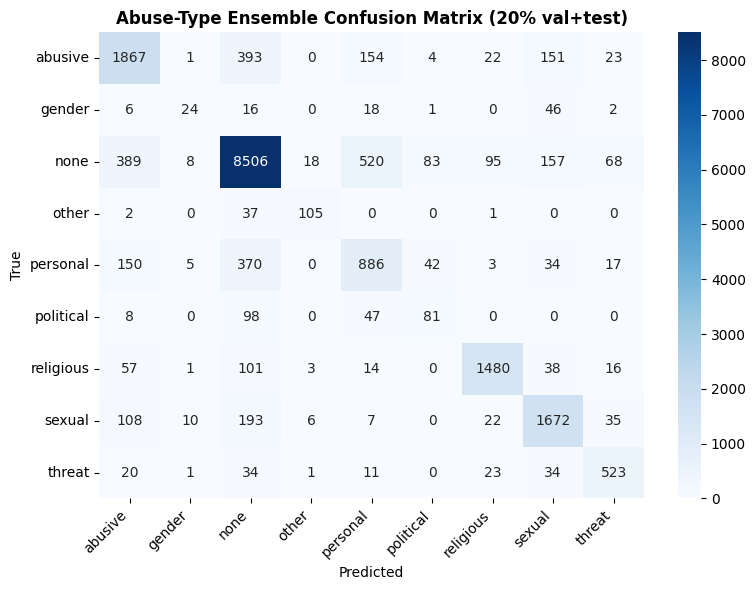

In [13]:
# ── FINAL EVAL — COMBINED HELD-OUT 20% (val+test). The ONLY reported split
#    (Point 3): weights were optimised on val (Section above), then the FROZEN
#    ensemble is evaluated on the val+test union. No standalone 10% test number.
from sklearn.metrics import (f1_score, accuracy_score, matthews_corrcoef,
                             classification_report, roc_auc_score, confusion_matrix)

final_metrics = {}
if opt_weights is not None and all("abuse_type" in v for v in test_logits_all.values()):
    comb_logits = {n: {"abuse_type": torch.cat([val_logits_all[n]["abuse_type"],
                                                test_logits_all[n]["abuse_type"]], 0)}
                   for n in val_logits_all}
    y_comb = np.concatenate([y_val_abuse, y_test_abuse])

    ens_abu   = ensemble_logits(comb_logits, opt_weights, "abuse_type")
    ens_abu   = logit_adjust(ens_abu, priors_la, tau=best_tau)
    abu_probs = torch.softmax(ens_abu, -1).numpy()
    abu_preds = ens_abu.argmax(-1).numpy()

    valid  = y_comb >= 0
    yt, yp = y_comb[valid], abu_preds[valid]
    pr     = abu_probs[valid]
    n_cls  = abu_probs.shape[1]

    abu_macro_f1 = f1_score(yt, yp, average="macro",    zero_division=0)
    abu_w_f1     = f1_score(yt, yp, average="weighted", zero_division=0)
    abu_acc      = accuracy_score(yt, yp)
    abu_mcc      = matthews_corrcoef(yt, yp)
    try:
        abu_auroc = roc_auc_score(yt, pr, multi_class="ovr", average="macro",
                                  labels=list(range(n_cls)))
    except Exception:
        abu_auroc = float("nan")

    abuse_classes = sorted(label_encoders["abuse_type"], key=lambda k: label_encoders["abuse_type"][k])
    none_id = label_encoders["abuse_type"].get("none", None)
    none_f1 = bin_equiv_f1 = bin_equiv_acc = bin_equiv_mcc = None
    if none_id is not None:
        per_class_f1 = f1_score(yt, yp, average=None, labels=list(range(n_cls)), zero_division=0)
        none_f1 = float(per_class_f1[none_id])
        yt_bin = (yt != none_id).astype(int)
        yp_bin = (yp != none_id).astype(int)
        bin_equiv_f1  = f1_score(yt_bin, yp_bin, average="macro", zero_division=0)
        bin_equiv_acc = accuracy_score(yt_bin, yp_bin)
        bin_equiv_mcc = matthews_corrcoef(yt_bin, yp_bin)

    final_metrics = {
        "eval_split": "combined_val_test_20pct",
        "n_samples": int(valid.sum()),
        "abuse_type_macro_f1":    round(float(abu_macro_f1), 4),
        "abuse_type_weighted_f1": round(float(abu_w_f1), 4),
        "abuse_type_accuracy":    round(float(abu_acc), 4),
        "abuse_type_mcc":         round(float(abu_mcc), 4),
        "abuse_type_macro_auroc": round(float(abu_auroc), 4),
        "none_class_f1_as_binary": round(none_f1, 4) if none_f1 is not None else None,
        "binary_equiv_macro_f1":   round(float(bin_equiv_f1), 4)  if bin_equiv_f1  is not None else None,
        "binary_equiv_accuracy":   round(float(bin_equiv_acc), 4) if bin_equiv_acc is not None else None,
        "binary_equiv_mcc":        round(float(bin_equiv_mcc), 4) if bin_equiv_mcc is not None else None,
    }

    print("="*64)
    print(f"FINAL ENSEMBLE — abuse-type (9-class) on COMBINED 20% (val+test), n={int(valid.sum()):,}")
    print("="*64)
    print(f"  Macro-F1    : {abu_macro_f1:.4f}   <- PRIMARY METRIC")
    print(f"  Weighted-F1 : {abu_w_f1:.4f}")
    print(f"  Accuracy    : {abu_acc:.4f}")
    print(f"  MCC         : {abu_mcc:.4f}")
    print(f"  Macro-AUROC : {abu_auroc:.4f}")
    if none_f1 is not None:
        print(f"  `none`-class F1 (binary-equivalent): {none_f1:.4f}")
        print(f"  Binary-equiv (none vs rest): F1={bin_equiv_f1:.4f}  Acc={bin_equiv_acc:.4f}  MCC={bin_equiv_mcc:.4f}")
    print("\nPer-class report (20% pool):")
    print(classification_report(yt, yp, target_names=abuse_classes, zero_division=0))

    os.makedirs("../outputs/ensemble", exist_ok=True)
    np.save("../outputs/ensemble/final20_abuse_preds.npy", abu_preds)
    np.save("../outputs/ensemble/final20_abuse_probs.npy", abu_probs)

    cm = confusion_matrix(yt, yp, labels=list(range(n_cls)))
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=abuse_classes, yticklabels=abuse_classes)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Abuse-Type Ensemble Confusion Matrix (20% val+test)", fontweight="bold")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    plt.savefig("../outputs/ensemble/cm_abuse_ensemble_20pct.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠ abuse_type logits not available or weights not optimised.")

## 5 — (Merged into Section 4)

In [14]:
print("Abuse-type evaluation completed in Section 4 above.")

Abuse-type evaluation completed in Section 4 above.


## 6 — Save Final Config

In [15]:
# ── Save final ensemble config + metrics (single-task abuse-type) ───────────
import json
if opt_weights is not None and final_metrics:
    os.makedirs("../outputs/ensemble", exist_ok=True)
    names = list(val_logits_all.keys())
    config = {
        "task": "abuse_type_9class_single_task",
        "ensemble_weights": {n: float(w) for n, w in zip(names, opt_weights)},
        "threshold": None,
        "metrics": final_metrics,
        "note": "Binary task removed. `none`-class F1 reported as binary-equivalent.",
    }
    with open("../outputs/ensemble/final_config.json", "w") as f:
        json.dump(config, f, indent=2)
    # Also write the metrics file NB07/NB10/NB11 read
    with open("../outputs/ensemble/ensemble_test_metrics.json", "w") as f:
        json.dump(final_metrics, f, indent=2)
    print("✅ Saved → ../outputs/ensemble/final_config.json")
    print("✅ Saved → ../outputs/ensemble/ensemble_test_metrics.json")
    print(json.dumps(final_metrics, indent=2))
else:
    print("⚠ Nothing to save — ensemble not computed.")


✅ Saved → ../outputs/ensemble/final_config.json
✅ Saved → ../outputs/ensemble/ensemble_test_metrics.json
{
  "eval_split": "combined_val_test_20pct",
  "n_samples": 18868,
  "abuse_type_macro_f1": 0.6694,
  "abuse_type_weighted_f1": 0.8028,
  "abuse_type_accuracy": 0.8026,
  "abuse_type_mcc": 0.7109,
  "abuse_type_macro_auroc": 0.9429,
  "none_class_f1_as_binary": 0.8683,
  "binary_equiv_macro_f1": 0.8631,
  "binary_equiv_accuracy": 0.8633,
  "binary_equiv_mcc": 0.7262
}


---
**Next:** `07_ablations_and_analysis.ipynb`